# Classifier Ablation Studies

In [1]:
import os
os.environ.update(OMP_NUM_THREADS="1", OPENBLAS_NUM_THREADS="1", MKL_NUM_THREADS="1")
os.environ["PYTHONWARNINGS"] = "ignore::UserWarning"

In [2]:
%load_ext autoreload
import sys, time, json, copy
from itertools import product
import functools, warnings
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
import pandas as pd
import seaborn as sns
from pathlib import Path
from fastnanoid import generate
from datetime import datetime
from joblib import Parallel, delayed
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

In [3]:
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
lib_path = project_root / "lib"
sys.path.insert(0, str(lib_path))        
sys.path.insert(0, str(project_root))   

In [4]:
%autoreload 2
from lib.graph_factory import GraphFactory, add_graph_plot
from lib.proj_const_estimator import ProjConstEstimator
from lib.utils import fetch_dataset, get_alphas, rng, seed, save_to_pkl, load_from_pkl
from lib.classifier import ByzClassifier, load_run, save_run
from lib.system import SystemSimulator
from lib.metrics import MetricsCalculator
from lib.config import BASE_CONF, NUM_NODES
from lib.simulation import load_dataset, clf_stage
from lib.preprocessor import FEATURE_NAMES, HEAVY_FEATURES

**Experiment Configuration**

In [5]:
EXP_NAME = 'baseline2'
RUN_DIR = os.path.join(Path().resolve(), EXP_NAME)
IMAGE_DIR = os.path.join(RUN_DIR, "images")
os.makedirs(RUN_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

config = copy.deepcopy(BASE_CONF)

# Globals
b = 5

# Target Pi
config['pi'] = (np.full(NUM_NODES, 1.0/NUM_NODES))
# config['pi-dir-alpha'] = 10
# pi = rng('dir','graphs').dirichlet(np.full(NUM_NODES,config['pi-dir-alpha']))
# config['pi'] = (pi / pi.sum())

# Classifier Training 
config['train']['b'] = b
config['train']['fpr_mean'] = 0.2
config['train']['fpr_spread'] = 0.05
config['train']['gamma_C'] = np.clip((config['train']['fpr_spread']*np.linspace(-1,1,NUM_NODES)) + \
                                     config['train']['fpr_mean'], 0, 0.95)

# System Simulation 
config['sys']['b'] = b
config['sys']['fpr_spread'] = 0.003

# Communication Graph
config['graph_type'] = 'erdos-renyi'
config['graph_weights'] = 'MH_gen'
config['graph_args'] = {
    'ba_m': 5,
    'ws_k': 6,
    'ws_p': 0.1,
    'rand_reg_deg':b+1,
    'geom_radius':0.6,
    'er_p':min(1.0, 3.0 * np.log(NUM_NODES) / NUM_NODES),
}
config['graph_args']['MH_target_pi'] = (1 - config['train']['gamma_C']) * config['pi']

# Miscellaneous
config['train']['clf_model'] = 'xgb'
config['data_heterogeneity'] = 100
config['reg_param'] = 1

# Notebook Variables
ATKS = ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM']
ALGS = ['RDSGD', 'ORACLE', 'IOS', 'SCC', 'TriMean', 'CooMed']
MODELS = ['rbf','lin-lr','mlp','xgb']
ALGS_TEST = ['RDSGD', 'ORACLE']
COLORS = dict(zip(MODELS, ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']))
LOCAL_SEED = 777
DEBUG = True

In [6]:
# Save experiment configuration
payload = copy.deepcopy(config)
del payload['train']['gamma_C']
del payload['pi']
del payload['graph_args']['MH_target_pi']
with open(os.path.join(RUN_DIR, f'config.json'), 'w') as f:
    def convert(o):
        if isinstance(o, np.generic):
            return o.item()
        raise TypeError(f'{type(o)} not serializable')
    json.dump(payload, f, indent=2, default=convert)

In [7]:
# Initialize Globals
gd = load_dataset()
gf = GraphFactory(config['train']['num_nodes'], b)

In [8]:
# Estimate Projection Constant
pce = ProjConstEstimator(config, gd, gf)
pce.configure(config, seed('proj-const-estimator'))
proj_const = pce.estimate()

### Sensitivity Analysis

In [13]:
sep, imp = {}, {}
for atk in ATKS:
    clf = ByzClassifier(config, gd, gf)
    clf.init_preproc()
    clf.init_simulation(config, proj_const, LOCAL_SEED)
    Xtr, ytr, gtr = clf.simulate(atk, LOCAL_SEED, config['train']['beta_C'], config['train']['gamma_C'])

    sep[atk] = {FEATURE_NAMES[f]: 2 * roc_auc_score(ytr, Xtr[:, f]) - 1 for f in range(Xtr.shape[1])}

    Xtr_s = clf.feat_pre_proc.fit_transform(Xtr)
    est, _ = clf.fit(in_data=dict(X_train=Xtr_s, y_train=ytr, groups_train=gtr))

    clf.init_simulation(config, proj_const, LOCAL_SEED+123)
    Xva, yva, _ = clf.simulate(atk, LOCAL_SEED+123, config['train']['beta_C'], config['train']['gamma_C'])
    r = permutation_importance(est, clf.feat_pre_proc.transform(Xva), yva,
                               scoring='average_precision', n_repeats=10,
                               random_state=seed('perm', atk))
    imp[atk] = dict(zip(clf.out_feat_names, r.importances_mean))

sep = pd.DataFrame(sep).T.reindex(columns=FEATURE_NAMES)
imp = pd.DataFrame(imp).T.reindex(columns=FEATURE_NAMES)

In [14]:
sep.to_csv(os.path.join(RUN_DIR,'feature_separability.csv'))
imp.to_csv(os.path.join(RUN_DIR,'feature_permutation_importance.csv'))

In [27]:
sep.round(6)

,cos_g,log_norm_ratio,margin,stable_rank,acc,cos_gbar,log_dev_norm,ce_diff_nbr,log_alpha
label_flip,-0.185391,0.998796,1.000000,-0.492139,-0.080299,0.317162,0.985142,0.948443,0.0
sign_flip,-0.027044,-0.103137,-0.298456,-0.003059,-0.026081,0.323216,-0.430273,0.030803,0.0
gaussian,0.098321,1.000000,-0.486541,0.968949,-1.000000,-0.765063,1.000000,1.000000,0.0
ALIE,0.959801,-0.944638,-0.217365,-0.633013,0.238357,0.935622,-1.000000,-0.751581,0.0
IPM,-0.886933,-0.998301,0.308370,0.268105,0.248652,0.846274,-0.999999,-0.848140,0.0


In [19]:
imp.round(6)

,cos_g,log_norm_ratio,margin,stable_rank,acc,cos_gbar,log_dev_norm,ce_diff_nbr,log_alpha
label_flip,0.000000,0.000004,0.407038,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000
sign_flip,-0.002068,-0.013777,0.174840,0.017995,0.012546,0.146251,0.136872,0.086908,0.033572
gaussian,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000005,0.000000
ALIE,0.018374,0.000000,0.000000,0.044138,0.000000,0.000000,0.466288,0.000000,0.000000
IPM,-0.000000,0.000111,0.000000,0.000000,0.000000,0.000042,0.436038,0.000002,0.000000


### Classifier Performance

In [9]:
clf = ByzClassifier(config, gd, gf)
sim_data = clf.run_simulations(config, proj_const, seed('byz-clf','sim'), is_printing=False)

In [10]:
rows = []
for model in MODELS:
    clf.fit(in_data=sim_data, in_model=model)
    op_pt = clf.calc_optimal_op_pt(in_data=sim_data)
    res = clf.test(in_data=sim_data)
    metrics = dict(model=model)
    metrics.update(dict(
        rec=clf.rec, prec=clf.prec, prevalence=clf.prevalence,
        op_rec=clf.op_rec, op_prec=clf.op_prec, 
        op_tau=op_pt['C_tau'] # central operating point around which downstream sys simulations are spread
    ))
    metrics.update(op_pt)
    metrics.update(res)
    rows.append(metrics)
df_clf_model_sel = pd.DataFrame(rows).set_index('model')

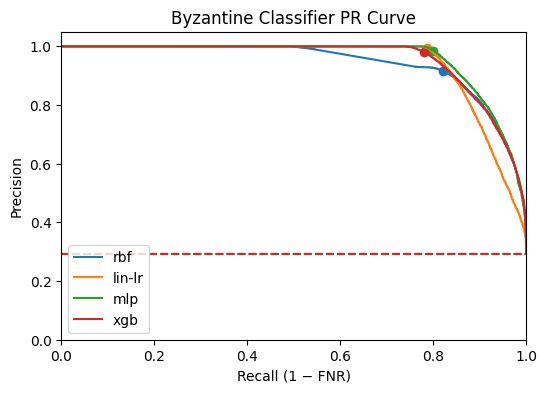

In [11]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
for m in MODELS:
    ax.plot(df_clf_model_sel.loc[m,'rec'],df_clf_model_sel.loc[m,'prec'], color=COLORS[m], label=m)
    ax.axhline(df_clf_model_sel.loc[m,'prevalence'], linestyle='--', color=COLORS[m])
    ax.scatter([df_clf_model_sel.loc[m,'op_rec']], [df_clf_model_sel.loc[m,'op_prec']], color=COLORS[m])
ax.legend()
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall (1 − FNR)')
ax.set_ylabel('Precision')
ax.set_title('Byzantine Classifier PR Curve')
ax.legend(loc='lower left')
fig.savefig(os.path.join(IMAGE_DIR,"precision_recall_curve.png"))
plt.show()

### Leave-One-Out Analysis

In [12]:
# LOO Analysis 
loo_seed = LOCAL_SEED + 888
rows = []
for atk in ATKS:
    train_atks = list(set(ATKS).difference({atk}))
    test_atk = atk
    print(f"train: {train_atks}, test: {test_atk}")

    clf_sim_data = clf.run_simulations(config, proj_const, loo_seed, 
                                       training_attacks=train_atks, testing_attacks=[test_atk], is_printing=False)
    C_best_est, C_pre_pipe = clf.fit()
    C_op_pt = clf.calc_optimal_op_pt()
    C_metrics = clf.test()

    run_results = dict()
    run_results.update(C_op_pt)
    run_results.update(C_metrics)
    run_results['train_atks'] = train_atks
    run_results['test_atk'] = test_atk
    rows.append(run_results)
df_loo = pd.DataFrame(rows).set_index('test_atk')

train: ['ALIE', 'gaussian', 'IPM', 'sign_flip'], test: label_flip



KeyboardInterrupt


KeyboardInterrupt



In [ ]:
df_loo1 = df_loo.drop(columns=['cv_params','train_atks']).rename(columns={
    'C_fpr':'val_fpr',
    'C_fnr':'val_fnr',
    'C_tau':'val_tau',
    'beta_C':'test_fnr',
    'gamma_C':'test_fpr',
})
df_loo1[['val_fpr','val_fnr', 'test_fpr', 'test_fnr', 'avg_prec', 'roc_auc']].to_csv(os.path.join(RUN_DIR,"loo_table.csv"))

### Train-Val Matrix

In [20]:
train_sim_data = dict()
train_sim_seed = LOCAL_SEED
for atk in ATKS:
    print(f'Building training set. Simulating {atk} (seed {train_sim_seed})')
    clf.init_simulation(config, proj_const, train_sim_seed)
    X, y, g = clf.simulate(atk, train_sim_seed, config['train']['beta_C'], config['train']['gamma_C'])
    train_sim_data[atk] = { 'X': X, 'y': y, 'g':g}

Building training set. Simulating label_flip (seed 777)
Building training set. Simulating sign_flip (seed 777)
Building training set. Simulating gaussian (seed 777)
Building training set. Simulating ALIE (seed 777)
Building training set. Simulating IPM (seed 777)


In [21]:
val_sim_data1 = dict()
val_sim_seed1 = LOCAL_SEED + 111
for atk in ATKS:
    print(f'Building validation set. Simulating {atk} (seed {val_sim_seed1})')
    clf.init_simulation(config, proj_const, val_sim_seed1)
    X, y, g = clf.simulate(atk, val_sim_seed1, config['train']['beta_C'], config['train']['gamma_C'])
    val_sim_data1[atk] = { 'X': X, 'y': y, 'g':g}

Building validation set. Simulating label_flip (seed 888)
Building validation set. Simulating sign_flip (seed 888)
Building validation set. Simulating gaussian (seed 888)
Building validation set. Simulating ALIE (seed 888)
Building validation set. Simulating IPM (seed 888)


In [22]:
val_sim_data2 = dict()
val_sim_seed2 = LOCAL_SEED + 222
for atk in ATKS:
    print(f'Building validation set. Simulating {atk} (seed {val_sim_seed2})')
    clf.init_simulation(config, proj_const, val_sim_seed2)
    X, y, g = clf.simulate(atk, val_sim_seed2, config['train']['beta_C'], config['train']['gamma_C'])
    val_sim_data2[atk] = { 'X': X, 'y': y, 'g':g}

Building validation set. Simulating label_flip (seed 999)
Building validation set. Simulating sign_flip (seed 999)
Building validation set. Simulating gaussian (seed 999)
Building validation set. Simulating ALIE (seed 999)
Building validation set. Simulating IPM (seed 999)


In [23]:
test_sim_data = dict()
test_sim_seed = LOCAL_SEED + 333
for atk in ATKS:
    print(f'Building test set. Simulating {atk} (seed {test_sim_seed})')
    clf.init_simulation(config, proj_const, test_sim_seed)
    X, y, g = clf.simulate(atk, test_sim_seed, config['train']['beta_C'], config['train']['gamma_C'])
    test_sim_data[atk] = { 'X': X, 'y': y, 'g':g}

Building test set. Simulating label_flip (seed 1110)
Building test set. Simulating sign_flip (seed 1110)
Building test set. Simulating gaussian (seed 1110)
Building test set. Simulating ALIE (seed 1110)
Building test set. Simulating IPM (seed 1110)


In [24]:
# 5x5 comparison grid
rows = []
for train_atk, test_atk in product(ATKS, ATKS):
    print(f"train: {train_atk}, test: {test_atk}")
    
    Xtr = train_sim_data[train_atk]['X']
    ytr = train_sim_data[train_atk]['y']
    gtr = train_sim_data[train_atk]['g']

    Xva = val_sim_data1[train_atk]['X']
    yva = val_sim_data1[train_atk]['y']
    gva = val_sim_data1[train_atk]['g']

    Xth = val_sim_data2[train_atk]['X']
    yth = val_sim_data2[train_atk]['y']
    gth = val_sim_data2[train_atk]['g']
    
    Xte = test_sim_data[test_atk]['X']
    yte = test_sim_data[test_atk]['y']
    gte = test_sim_data[test_atk]['g']
    
    clf.init_preproc()
    data_payload = dict(
        X_train=clf.feat_pre_proc.fit_transform(Xtr), y_train=ytr,
        groups_train=gtr, atk_train=list(train_atk),
        X_val=clf.feat_pre_proc.transform(Xva), y_val=yva,
        groups_val=gva, atk_val=list(train_atk),
        X_thr=clf.feat_pre_proc.transform(Xth), y_thr=yth,
        groups_thr=gth, atk_thr=list(train_atk),
        X_test=clf.feat_pre_proc.transform(Xte), y_test=yte,
        groups_test=gte, atk_test=list(test_atk),
        attack_names=list(train_atk),
        test_attack_names=list(test_atk))
    
    # Fitting model to training data
    C_best_est, C_pre_pipe = clf.fit(in_data=data_payload)

    # Calculating optimal operating point using validation set
    C_opt_pt = clf.calc_optimal_op_pt(in_data=data_payload)

    # Testing the classifier on test set
    C_metrics = clf.test(in_data=data_payload)

    run_results = dict()
    run_results.update(C_opt_pt)
    run_results.update(C_metrics)
    run_results['train_atk'] = train_atk
    run_results['test_atk'] = test_atk
    rows.append(run_results)

train: label_flip, test: label_flip
train: label_flip, test: sign_flip
train: label_flip, test: gaussian
train: label_flip, test: ALIE
train: label_flip, test: IPM
train: sign_flip, test: label_flip
train: sign_flip, test: sign_flip
train: sign_flip, test: gaussian
train: sign_flip, test: ALIE
train: sign_flip, test: IPM
train: gaussian, test: label_flip
train: gaussian, test: sign_flip
train: gaussian, test: gaussian
train: gaussian, test: ALIE
train: gaussian, test: IPM
train: ALIE, test: label_flip
train: ALIE, test: sign_flip
train: ALIE, test: gaussian
train: ALIE, test: ALIE
train: ALIE, test: IPM
train: IPM, test: label_flip
train: IPM, test: sign_flip
train: IPM, test: gaussian
train: IPM, test: ALIE
train: IPM, test: IPM


In [25]:
df1 = pd.DataFrame(rows)
df1.set_index(['train_atk', 'test_atk'], inplace=True)

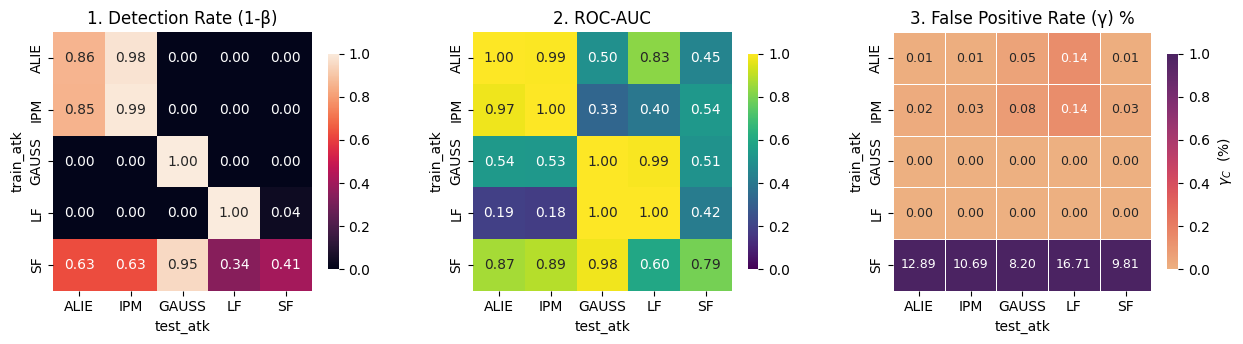

In [26]:
LABEL = {'label_flip': 'LF', 'sign_flip': 'SF', 'gaussian': 'GAUSS', 'ALIE': 'ALIE', 'IPM': 'IPM'}

fig, ax = plt.subplots(1,3,figsize=(15,4))

ax[0].set_title('1. Detection Rate (1-β)') 
sns.heatmap((1 - df1['beta_C']).unstack().rename(index=LABEL, columns=LABEL),
            annot=True, fmt='.2f', cmap='rocket', vmin=0, vmax=1,
            square=True, ax=ax[0], cbar_kws={'shrink': 0.7})

ax[1].set_title('2. ROC-AUC') 
sns.heatmap((df1['roc_auc']).unstack().rename(index=LABEL, columns=LABEL), 
            annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1, 
            square=True, cbar_kws={'shrink': 0.7}, ax=ax[1])

# ax[1,0].set_title('3. Threshold Miscalibration') 
# sns.heatmap((df1['roc_auc'] - (1 - df1['beta_C'])).unstack().rename(index=LABEL, columns=LABEL), 
#             annot=True, cbar_kws={'shrink': 0.7}, fmt='.2f', cmap='rocket', vmin=0, vmax=1, square=True, ax=ax[1,0])

ax[2].set_title('3. False Positive Rate (γ) %') 
sns.heatmap((df1['gamma_C']*100).unstack().rename(index=LABEL, columns=LABEL), 
            annot=True, fmt='.2f', annot_kws={'size': 9}, 
            cbar_kws={'shrink': 0.7, 'label': '$\\gamma_C$  (%)'},
            linewidths=0.6, linecolor='white', square=True,
            cmap='flare', vmin=0, vmax=1, ax=ax[2])

fig.subplots_adjust(wspace=0.3, hspace=0.2)
fig.savefig(os.path.join(IMAGE_DIR,"clf_train_test_matrix.png"))